# Seoul Bike Sharing Demand: EDA and preprocessing

**Task I am solving:** regression preparation for `Rented Bike Count`.

**External context checked:** UCI says this dataset has 8,760 hourly records, no missing values, and is intended for regression. It also defines the columns as rented bike count, date/hour, weather, season, holiday, and functioning-day information.

Sources used for context only:
- UCI dataset page: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand
- scikit-learn OneHotEncoder docs: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- scikit-learn TimeSeriesSplit docs: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html

I will not assume the data is clean just because UCI says so. The local CSV is checked directly before preprocessing.


## 1. Imports and path

Overall logic: load only the libraries already useful for this dataset step.

Line by line:
- `numpy` is needed for cyclic clock/calendar features.
- `pandas` is needed for tabular EDA and preprocessing.
- `matplotlib` and `seaborn` are used only for a small visual check.
- `OneHotEncoder` is used because `season` and `holiday` are text categories.
- `TimeSeriesSplit` is kept for later model validation because the rows are time ordered.
- `csv_path` points to the local CSV in this notebook folder.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 40)
csv_path = "SeoulBikeData.csv"

## 2. Load the CSV

Overall logic: read the file with the encoding proven by the raw header bytes.

Line by line:
- `pd.read_csv` loads the local dataset.
- `encoding="cp1252"` is needed because the degree symbol is stored as byte `0xb0`; this gives `°C` instead of a broken header.
- `raw.shape` confirms the local row and column count before any changes.


In [4]:
raw = pd.read_csv(csv_path, encoding="cp1252")
raw.shape

(8760, 14)

## 3. Inspect the raw columns

Overall logic: look at the original names and first rows before changing anything.

Line by line:
- `raw.head()` shows the first records.
- This connects to the load step by confirming that dates, target, weather, and text columns were read correctly.


In [5]:
raw.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 4. Clean names and create timestamp

Overall logic: make names stable and build one hourly timestamp from `date` and `hour`.

Line by line:
- `data = raw.copy()` protects the original table.
- `data.columns = ...` removes spaces, symbols, and unit text from names while keeping meaning.
- `pd.to_datetime(..., dayfirst=True)` is needed because the first date is `01/12/2017`, meaning 1 December 2017 in this dataset.
- `pd.to_timedelta(..., unit="h")` turns the hour column into an hourly offset.
- `sort_values` keeps the later time checks and model validation order honest.


In [7]:
data = raw.copy()

data.columns = [
    "date",
    "rented_bike_count",
    "hour",
    "temperature_c",
    "humidity_percent",
    "wind_speed_m_s",
    "visibility_10m",
    "dew_point_temperature_c",
    "solar_radiation_mj_m2",
    "rainfall_mm",
    "snowfall_cm",
    "season",
    "holiday",
    "functioning_day",
]

data["date"] = pd.to_datetime(data["date"], dayfirst=True)
data["timestamp"] = data["date"] + pd.to_timedelta(data["hour"], unit="h")
data = data.sort_values("timestamp").reset_index(drop=True)

data.head()

,date,rented_bike_count,hour,temperature_c,humidity_percent,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,season,holiday,functioning_day,timestamp
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 03:00:00
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 04:00:00


## 5. Data quality check

Overall logic: check missing values, data types, and cardinality before deciding preprocessing.

Line by line:
- `missing` tells whether imputation is needed.
- `unique` shows which columns are continuous, discrete, or categorical.
- `dtype` catches columns that were parsed wrongly.


In [8]:
quality = pd.DataFrame({"missing": data.isna().sum(),"unique": data.nunique(), "dtype": data.dtypes.astype(str)})
quality

,missing,unique,dtype
date,0,365,datetime64[us]
rented_bike_count,0,2166,int64
hour,0,24,int64
temperature_c,0,546,float64
humidity_percent,0,90,int64
wind_speed_m_s,0,65,float64
visibility_10m,0,1789,int64
dew_point_temperature_c,0,556,float64
solar_radiation_mj_m2,0,345,float64
rainfall_mm,0,61,float64


## 6. Duplicate and time-continuity check

Overall logic: because this is hourly data, time order matters.

Line by line:
- `duplicated().sum()` checks repeated full rows.
- `min` and `max` show the covered time window.
- `nunique` on dates confirms the number of days.
- `gap_hours.value_counts()` checks whether the timestamp moves by one hour each row.


In [ ]:
gap_hours = data["timestamp"].diff().dt.total_seconds().div(3600)

pd.Series({"rows": len(data),"duplicate_rows": data.duplicated().sum(),"first_timestamp": data["timestamp"].min(),
           "last_timestamp": data["timestamp"].max(),
    "unique_dates": data["date"].nunique(),
    "gap_values": gap_hours.dropna().value_counts().to_dict()})

rows                              8760
duplicate_rows                       0
first_timestamp    2017-12-01 00:00:00
last_timestamp     2018-11-30 23:00:00
unique_dates                       365
gap_values                 {1.0: 8759}
dtype: object

## 7. Numeric column behavior

Overall logic: inspect numeric ranges before transforming anything.

Line by line:
- `select_dtypes("number")` focuses only on numeric columns.
- `describe().T` gives count, center, spread, and min/max for each numeric variable.
- `round(2)` keeps the table readable.


In [7]:
data.select_dtypes("number").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
rented_bike_count,8760.0,704.60,645.00,0.0,191.00,504.50,1065.25,3556.00
hour,8760.0,11.50,6.92,0.0,5.75,11.50,17.25,23.00
temperature_c,8760.0,12.88,11.94,-17.8,3.50,13.70,22.50,39.40
humidity_percent,8760.0,58.23,20.36,0.0,42.00,57.00,74.00,98.00
wind_speed_m_s,8760.0,1.72,1.04,0.0,0.90,1.50,2.30,7.40
visibility_10m,8760.0,1436.83,608.30,27.0,940.00,1698.00,2000.00,2000.00
dew_point_temperature_c,8760.0,4.07,13.06,-30.6,-4.70,5.10,14.80,27.20
solar_radiation_mj_m2,8760.0,0.57,0.87,0.0,0.00,0.01,0.93,3.52
rainfall_mm,8760.0,0.15,1.13,0.0,0.00,0.00,0.00,35.00
snowfall_cm,8760.0,0.08,0.44,0.0,0.00,0.00,0.00,8.80


## 8. Categorical value check

Overall logic: understand every text column before encoding.

Line by line:
- `value_counts()` shows the exact categories and their frequencies.
- The dictionary keeps the three related tables together without extra helper code.


In [8]:
category_counts = {
    col: data[col].value_counts()
    for col in ["season", "holiday", "functioning_day"]
}

category_counts

{'season': season
 Spring    2208
 Summer    2208
 Autumn    2184
 Winter    2160
 Name: count, dtype: int64,
 'holiday': holiday
 No Holiday    8328
 Holiday        432
 Name: count, dtype: int64,
 'functioning_day': functioning_day
 Yes    8465
 No      295
 Name: count, dtype: int64}

## 9. Target behavior by functioning day

Overall logic: check whether non-functioning rows describe real demand or system closure.

Line by line:
- `groupby("functioning_day")` separates operating and non-operating rows.
- `count`, `min`, `median`, `max`, and `sum` show whether the target behaves normally in both groups.
- This directly supports the later choice to train demand data only on functioning rows.


In [9]:
data.groupby("functioning_day")["rented_bike_count"].agg([
    "count",
    "min",
    "median",
    "max",
    "sum",
])

,count,min,median,max,sum
functioning_day,,,,,
No,295,0,0.0,0,0
Yes,8465,2,542.0,3556,6172314


## 10. Target behavior by time and known categories

Overall logic: check whether hour, month, weekday, season, and holiday have visible signal.

Line by line:
- `assign` creates temporary calendar columns without changing `data`.
- Each `groupby` compares the target across one perspective.
- These outputs decide which time/category fields are worth keeping.


In [10]:
calendar_view = data.assign(
    month=data["date"].dt.month,
    day_name=data["date"].dt.day_name(),
)

hour_target = data.groupby("hour")["rented_bike_count"].agg([
    "median",
    "mean",
])

month_target = calendar_view.groupby("month")["rented_bike_count"].agg([
    "median",
    "mean",
])

weekday_target = calendar_view.groupby("day_name")["rented_bike_count"].agg([
    "median",
    "mean",
])

season_holiday_target = data.groupby([
    "season",
    "holiday",
])["rented_bike_count"].agg(["count", "median", "mean"])

hour_target.round(1), month_target.round(1), weekday_target.round(1), season_holiday_target.round(1)

(      median    mean
 hour                
 0      513.0   541.5
 1      401.0   426.2
 2      265.0   301.6
 3      176.0   203.3
 4      119.0   132.6
 5      129.0   139.1
 6      232.0   287.6
 7      426.0   606.0
 8      728.0  1015.7
 9      680.0   646.0
 10     581.0   527.8
 11     624.0   600.9
 12     709.0   699.4
 13     727.0   733.2
 14     733.0   758.8
 15     785.0   829.2
 16     911.0   930.6
 17    1184.0  1138.5
 18    1548.0  1502.9
 19    1224.0  1195.1
 20    1062.0  1069.0
 21    1046.0  1031.4
 22     949.0   922.8
 23     656.0   671.1,
        median    mean
 month                
 1       181.5   201.6
 2       195.0   225.9
 3       460.0   511.6
 4       655.0   728.1
 5       874.0   950.4
 6      1144.5  1245.7
 7       829.5   987.2
 8       732.5   876.2
 9       915.0   935.6
 10      870.0   874.6
 11      650.0   646.8
 12      236.5   249.1,
            median   mean
 day_name                
 Friday      566.0  747.1
 Monday      533.0  730.6


## 11. Small visual check

Overall logic: use plots only where they add evidence beyond tables.

Line by line:
- The first plot shows target spread by season.
- The second plot shows the hourly demand curve.
- `tight_layout` avoids overlap in the notebook output.


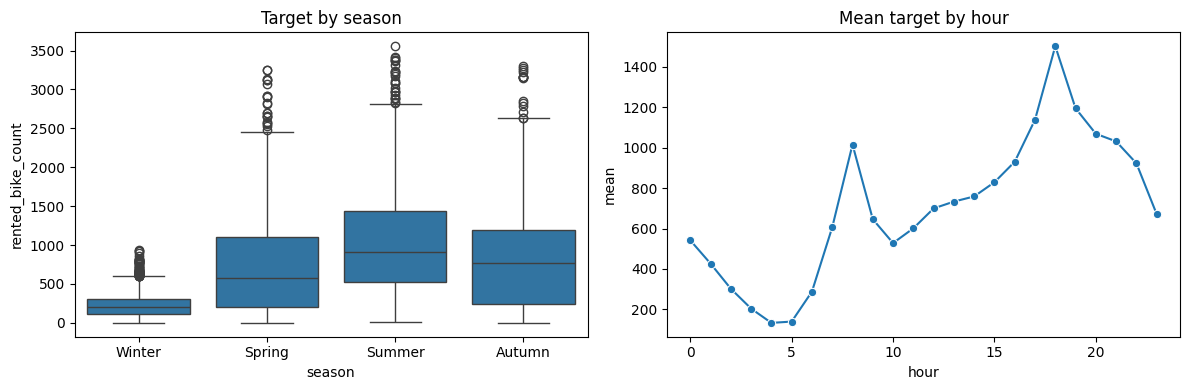

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(
    data=data,
    x="season",
    y="rented_bike_count",
    ax=axes[0],
)

sns.lineplot(
    data=hour_target.reset_index(),
    x="hour",
    y="mean",
    marker="o",
    ax=axes[1],
)

axes[0].set_title("Target by season")
axes[1].set_title("Mean target by hour")
plt.tight_layout()

## 12. Numeric relationship check on functioning rows

Overall logic: after the closure check, correlations should be read on functioning rows only.

Line by line:
- `yes_data` keeps rows where the system was operating.
- `corr()` gives simple linear relationships with the target.
- The zero-rate table checks sparse weather-event columns instead of treating many zeros as missing.


In [12]:
yes_data = data[data["functioning_day"].eq("Yes")]

corr_with_target = yes_data.select_dtypes("number").corr()[
    "rented_bike_count"
].sort_values(ascending=False)

event_cols = [
    "rainfall_mm",
    "snowfall_cm",
    "solar_radiation_mj_m2",
]

zero_rate = yes_data[event_cols].eq(0).mean().mul(100)

corr_with_target.round(3), zero_rate.round(1).to_frame("zero_percent")

(rented_bike_count          1.000
 temperature_c              0.563
 hour                       0.425
 dew_point_temperature_c    0.400
 solar_radiation_mj_m2      0.274
 visibility_10m             0.212
 wind_speed_m_s             0.125
 rainfall_mm               -0.129
 snowfall_cm               -0.152
 humidity_percent          -0.202
 Name: rented_bike_count, dtype: float64,
                        zero_percent
 rainfall_mm                    93.9
 snowfall_cm                    94.8
 solar_radiation_mj_m2          49.0)

## 13. Preprocessing decisions

Evidence-based decisions:

1. No imputation is needed because the local check found zero missing values.
2. Duplicate removal is not needed because the local check found zero duplicate rows.
3. For demand modeling, keep only `functioning_day == "Yes"`. The `No` rows have target sum 0, so they describe closure behavior, not normal rental demand.
4. Drop `functioning_day` after that filter because it becomes constant.
5. Keep weather variables as numeric. Rain and snow are mostly zero, but those zeros mean no event, not missing data.
6. Convert hour, weekday, and month to sine/cosine features because they are cycles. Hour 23 and hour 0 are close in real time.
7. One-hot encode `season` and `holiday` because they are unordered text categories.
8. Do not scale here because the final model type is unknown. Scaling can be added inside the training pipeline when the chosen estimator needs it.
9. Use time-aware validation later. Random validation can mix future records into training. scikit-learn recommends `TimeSeriesSplit` for ordered samples.


## 14. Build training-ready data

Overall logic: create the regression target and numeric feature matrix.

Line by line:
- `model_data` filters to functioning rows based on the target evidence.
- Calendar columns come from the verified timestamp fields.
- Sine/cosine columns encode cycles without adding arbitrary thresholds.
- `categorical_cols` identifies text columns that need one-hot encoding.
- `numeric_cols` lists numeric features kept for training.
- `OneHotEncoder(handle_unknown="ignore")` makes future unseen categories transform safely.
- `X_ready` combines numeric and encoded categorical features.
- `y` is the regression target.


In [13]:
model_data = yes_data.copy()

model_data["month"] = model_data["date"].dt.month
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["hour_sin"] = np.sin(2 * np.pi * model_data["hour"] / 24)
model_data["hour_cos"] = np.cos(2 * np.pi * model_data["hour"] / 24)
model_data["dow_sin"] = np.sin(2 * np.pi * model_data["day_of_week"] / 7)
model_data["dow_cos"] = np.cos(2 * np.pi * model_data["day_of_week"] / 7)
model_data["month_sin"] = np.sin(2 * np.pi * model_data["month"] / 12)
model_data["month_cos"] = np.cos(2 * np.pi * model_data["month"] / 12)

categorical_cols = ["season", "holiday"]

numeric_cols = [
    "temperature_c",
    "humidity_percent",
    "wind_speed_m_s",
    "visibility_10m",
    "dew_point_temperature_c",
    "solar_radiation_mj_m2",
    "rainfall_mm",
    "snowfall_cm",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
)

encoded = encoder.fit_transform(model_data[categorical_cols])
encoded = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=model_data.index,
)

X_ready = pd.concat([model_data[numeric_cols], encoded], axis=1)
y = model_data["rented_bike_count"]

X_ready.shape, y.shape

((8465, 20), (8465,))

## 15. Prepared feature preview

Overall logic: inspect the actual training table after preprocessing.

Line by line:
- `head()` checks the columns are numeric and aligned.
- This connects to the previous cell by showing the result, not just the shape.


In [14]:
X_ready.head()

,temperature_c,humidity_percent,wind_speed_m_s,visibility_10m,dew_point_temperature_c,solar_radiation_mj_m2,rainfall_mm,snowfall_cm,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,season_Autumn,season_Spring,season_Summer,season_Winter,holiday_Holiday,holiday_No Holiday
0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0.000000,1.000000,-0.433884,-0.900969,-2.449294e-16,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0.258819,0.965926,-0.433884,-0.900969,-2.449294e-16,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0.500000,0.866025,-0.433884,-0.900969,-2.449294e-16,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0.707107,0.707107,-0.433884,-0.900969,-2.449294e-16,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0.866025,0.500000,-0.433884,-0.900969,-2.449294e-16,1.0,0.0,0.0,0.0,1.0,0.0,1.0


## 16. Validation object for later modeling

Overall logic: prepare the validation method without training a model yet.

Line by line:
- `TimeSeriesSplit()` keeps future rows out of earlier training folds.
- I do not set a custom split count because there is no dataset-specific evidence here for a custom value.


In [15]:
cv = TimeSeriesSplit()
cv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

## 17. Final verification

Overall logic: make one small, direct check that the prepared data is usable.

Line by line:
- The first assert confirms feature and target rows match.
- The second assert confirms no missing feature values remain.
- The third assert confirms no text columns remain in `X_ready`.
- The fourth assert confirms the regression target is non-negative.
- The final tuple reports the ready feature and target shapes.


In [16]:
assert X_ready.shape[0] == y.shape[0]
assert X_ready.isna().sum().sum() == 0
assert X_ready.select_dtypes("object").empty
assert y.ge(0).all()

X_ready.shape, y.shape

((8465, 20), (8465,))